In [1]:
# CELL 1: Importation des librairies et chargement du dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
# Affichage des tableaux : toutes les colonnes, sur une largeur de 200 caractères
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

# Chargement du dataset
df = pd.read_csv('../data/raw/weatherAUS.csv')

# Aperçu du dataset chargé
print("Dataset chargé avec succès!")
print(f"\nDimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nPremières 5 lignes:")
df.head()

Dataset chargé avec succès!

Dimensions: 145460 lignes × 23 colonnes

Colonnes: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

Premières 5 lignes:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [2]:
# CELL 2.A: Informations de base sur le dataset et valeurs manquantes

print("="*60)
print("INFORMATIONS GÉNÉRALES")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("ANALYSE DES VALEURS MANQUANTES")
print("="*60)

# Calcul des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df)) * 100
})

# Trier par pourcentage décroissant
missing_data = missing_data[missing_data['Nombre_Missing'] > 0].sort_values(
    'Pourcentage_Missing', ascending=False
)

print("\nVariables avec valeurs manquantes:")
print(missing_data)

# Lignes avec au moins une valeur manquante
nb_lignes_manquantes = df.isnull().any(axis=1).sum()
print(f"\nLignes avec au moins une valeur manquante: {nb_lignes_manquantes} ({nb_lignes_manquantes/len(df)*100:.2f}%)")

INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89


Variables avec valeurs manquantes:
                     Colonne  Nombre_Missing  Pourcentage_Missing
Sunshine            Sunshine           69835            48.009762
Evaporation      Evaporation           62790            43.166506
Cloud3pm            Cloud3pm           59358            40.807095
Cloud9am            Cloud9am           55888            38.421559
Pressure9am      Pressure9am           15065            10.356799
Pressure3pm      Pressure3pm           15028            10.331363
WindDir9am        WindDir9am           10566             7.263853
WindGustDir      WindGustDir           10326             7.098859
WindGustSpeed  WindGustSpeed           10263             7.055548
Humidity3pm      Humidity3pm            4507             3.098446
WindDir3pm        WindDir3pm            4228             2.906641
Temp3pm              Temp3pm            3609             2.481094
RainTomorrow    RainTomorrow            3267             2.245978
Rainfall            Rainfall            


Lignes avec au moins une valeur manquante: 89040 (61.21%)


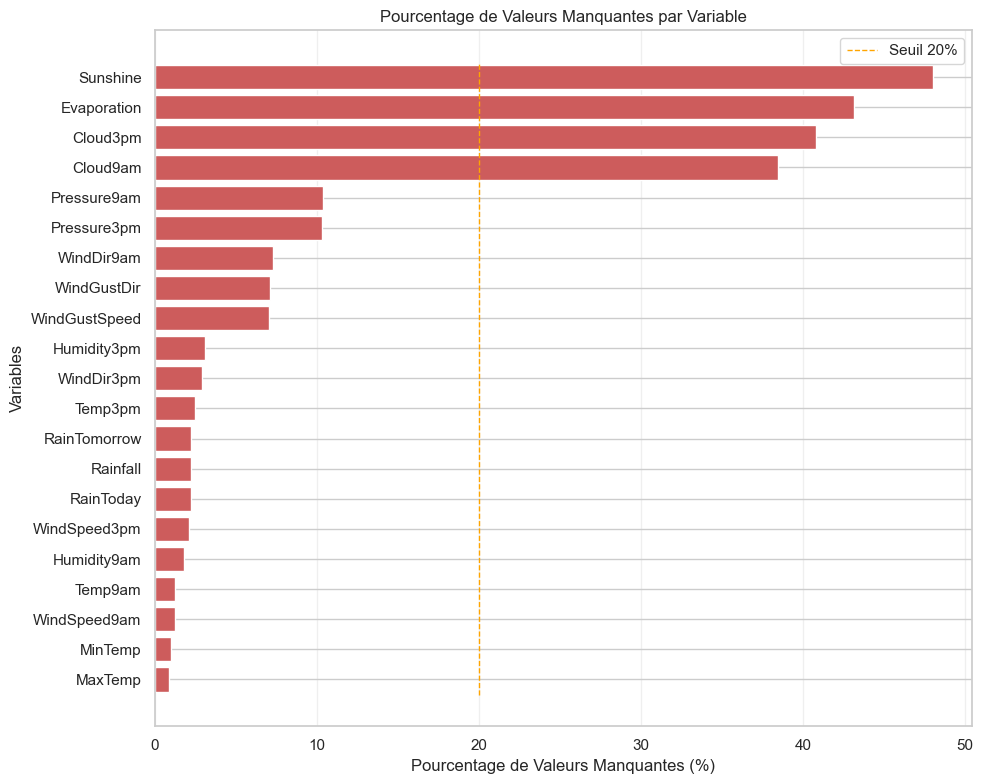

In [3]:
# CELL 2.B: Visualisation des valeurs manquantes

# Calcul des pourcentages de valeurs manquantes
missing_data = pd.DataFrame({
    'Variable': df.columns,
    'Pourcentage_Missing': (df.isnull().sum() / len(df)) * 100
})

# Garder seulement les variables avec des valeurs manquantes
missing_data = missing_data[missing_data['Pourcentage_Missing'] > 0].sort_values(
    'Pourcentage_Missing', ascending=True
)

# Graphique en barres horizontales
plt.figure(figsize=(10, 8))
plt.barh(missing_data['Variable'], missing_data['Pourcentage_Missing'], color='indianred')
# Ligne de référence du seuil de 20%
plt.plot([20, 20], [-0.5, len(missing_data) - 0.5], color='orange', linestyle='--', linewidth=1, label='Seuil 20%')
plt.xlabel('Pourcentage de Valeurs Manquantes (%)')
plt.ylabel('Variables')
plt.title('Pourcentage de Valeurs Manquantes par Variable')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/etape1_01_valeurs_manquantes.png', dpi=150)
plt.show()

Lignes entièrement dupliquées: 0
Couples (Location, Date) dupliqués: 0

Répartition de RainTomorrow (proportions):
RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64


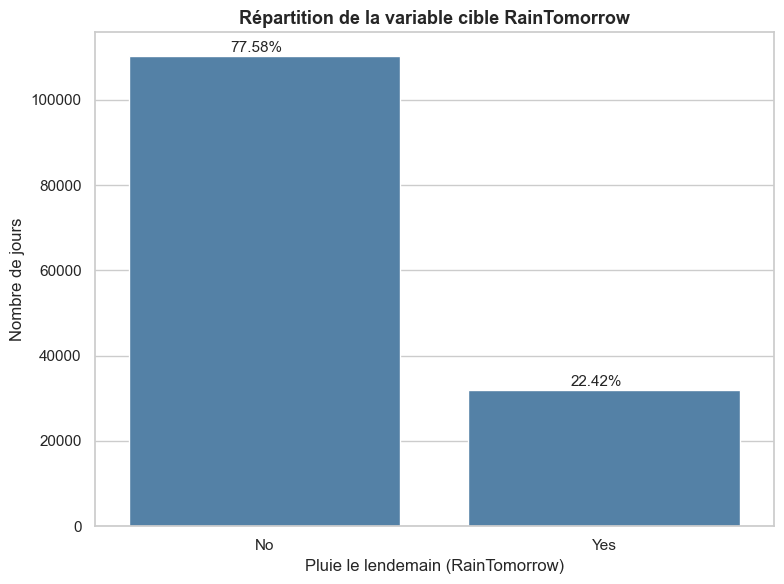

In [4]:
# CELL 2.C: Doublons et répartition de la variable cible

# Doublons : lignes entièrement identiques, puis couples (Location, Date) répétés
print(f"Lignes entièrement dupliquées: {df.duplicated().sum()}")
print(f"Couples (Location, Date) dupliqués: {df.duplicated(subset=['Location', 'Date']).sum()}")

# Répartition de la variable cible (proportions, valeurs manquantes exclues)
print("\nRépartition de RainTomorrow (proportions):")
print(df['RainTomorrow'].value_counts(normalize=True))

# Graphique de la répartition de la cible, avec le pourcentage au-dessus de chaque barre
ordre_cible = ['No', 'Yes']
effectifs_cible = df['RainTomorrow'].value_counts()
proportions_cible = df['RainTomorrow'].value_counts(normalize=True)

plt.figure(figsize=(8, 6))
sns.countplot(x='RainTomorrow', data=df, order=ordre_cible, color='steelblue')
# Texte décalé vers la gauche pour rester centré sur sa barre, juste au-dessus de la barre
plt.text(-0.1, effectifs_cible['No'] + 1000, f"{proportions_cible['No'] * 100:.2f}%", fontsize=11)
plt.text(0.9, effectifs_cible['Yes'] + 1000, f"{proportions_cible['Yes'] * 100:.2f}%", fontsize=11)
plt.title("Répartition de la variable cible RainTomorrow", fontsize=13, fontweight='bold')
plt.xlabel("Pluie le lendemain (RainTomorrow)")
plt.ylabel("Nombre de jours")
plt.tight_layout()
plt.savefig('../figures/etape1_14_repartition_cible.png', dpi=150)
plt.show()

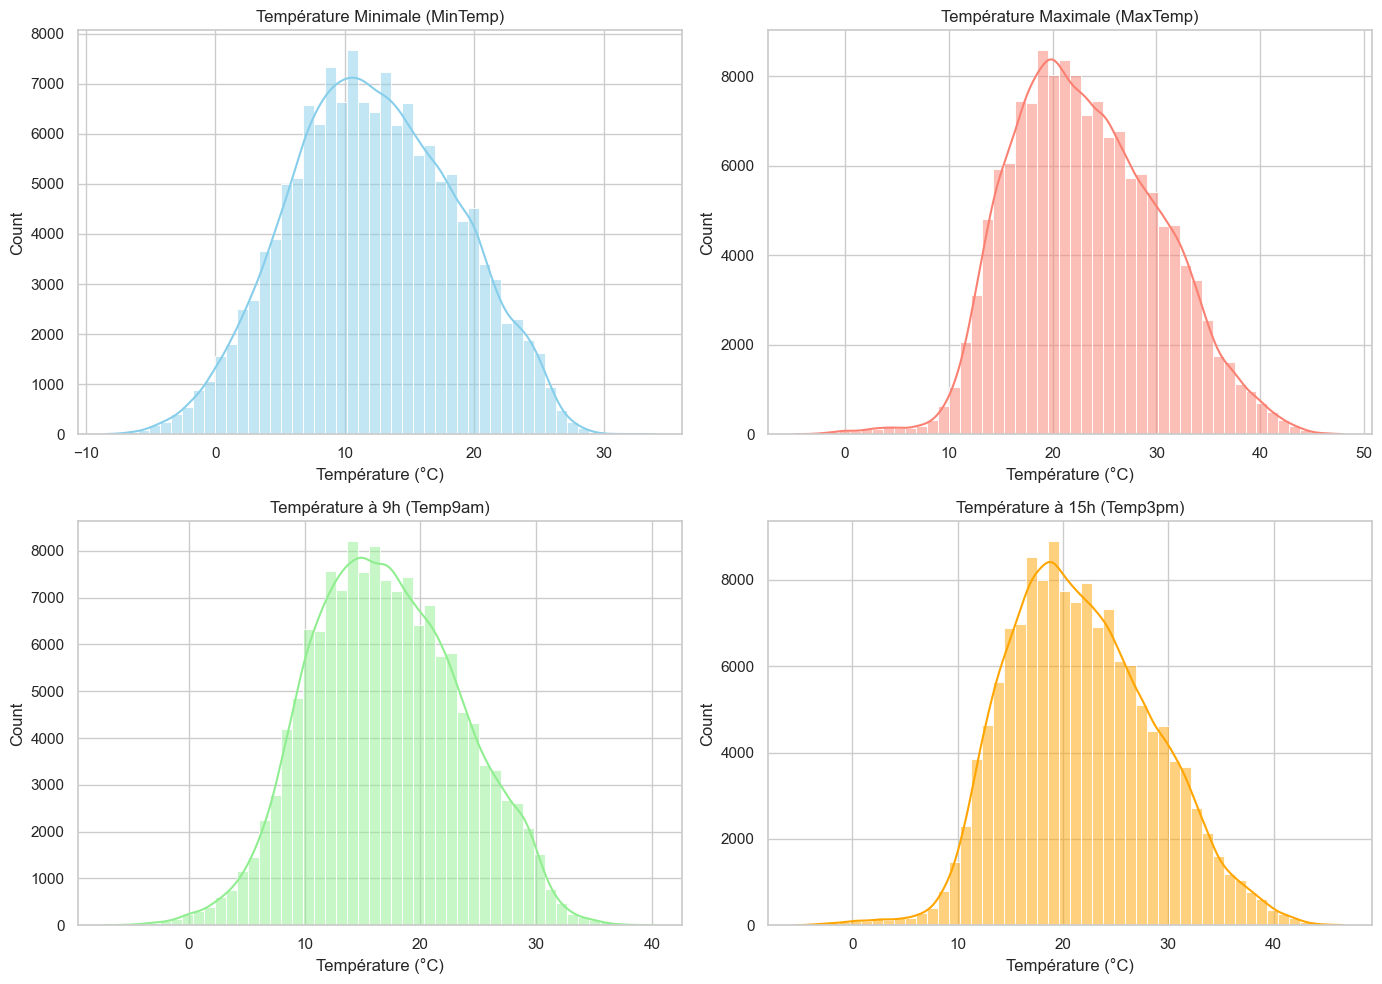

In [5]:
# CELL 3.A: Distribution des températures

plt.figure(figsize=(14, 10))

plt.subplot(221)
sns.histplot(df['MinTemp'], bins=50, color='skyblue', kde=True)
plt.title('Température Minimale (MinTemp)')
plt.xlabel('Température (°C)')

plt.subplot(222)
sns.histplot(df['MaxTemp'], bins=50, color='salmon', kde=True)
plt.title('Température Maximale (MaxTemp)')
plt.xlabel('Température (°C)')

plt.subplot(223)
sns.histplot(df['Temp9am'], bins=50, color='lightgreen', kde=True)
plt.title('Température à 9h (Temp9am)')
plt.xlabel('Température (°C)')

plt.subplot(224)
sns.histplot(df['Temp3pm'], bins=50, color='orange', kde=True)
plt.title('Température à 15h (Temp3pm)')
plt.xlabel('Température (°C)')

plt.tight_layout()
plt.savefig('../figures/etape1_02_distribution_temperatures.png', dpi=150)
plt.show()

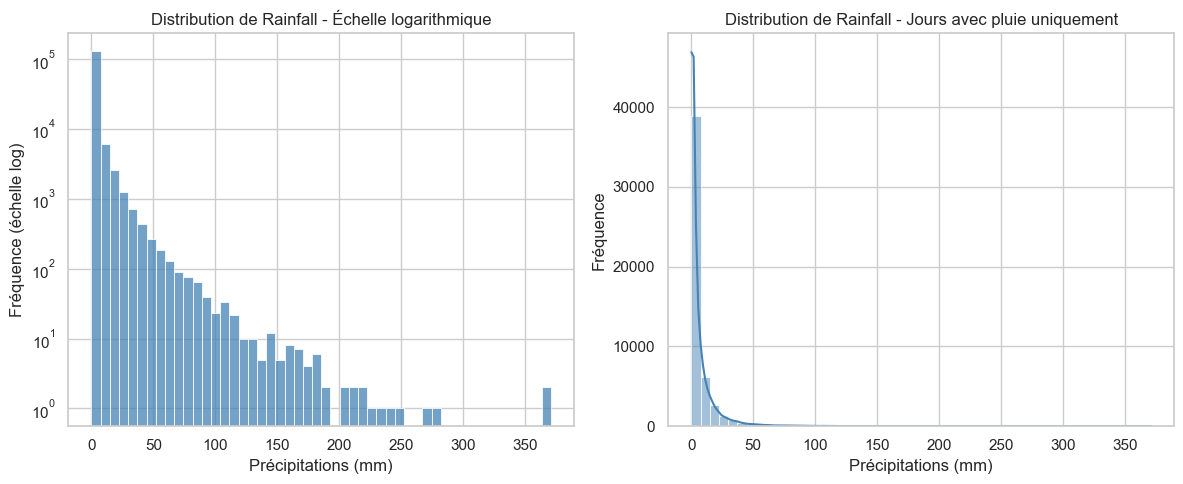

In [6]:
# CELL 3.B: Distribution de Rainfall (échelle logarithmique)

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Rainfall'], bins=50, color='steelblue', kde=False)
plt.yscale('log')
plt.title('Distribution de Rainfall - Échelle logarithmique')
plt.xlabel('Précipitations (mm)')
plt.ylabel('Fréquence (échelle log)')

plt.subplot(122)
sns.histplot(df['Rainfall'][df['Rainfall'] > 0], bins=50, color='steelblue', kde=True)
plt.title('Distribution de Rainfall - Jours avec pluie uniquement')
plt.xlabel('Précipitations (mm)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../figures/etape1_03_distribution_rainfall.png', dpi=150)
plt.show()

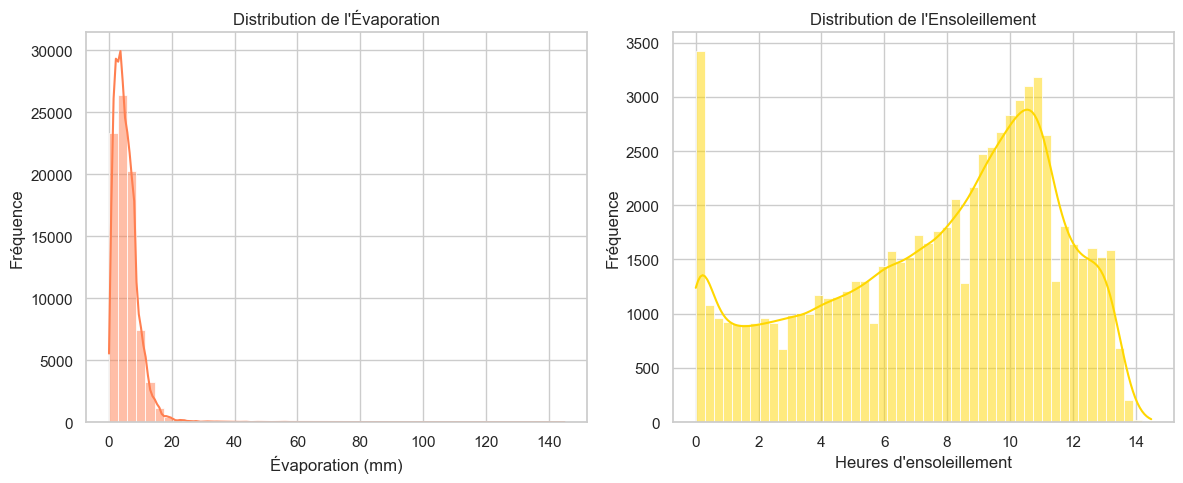

In [7]:
# CELL 3.C: Distribution de l'évaporation et de l'ensoleillement

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Evaporation'], bins=50, color='coral', kde=True)
plt.title('Distribution de l\'Évaporation')
plt.xlabel('Évaporation (mm)')
plt.ylabel('Fréquence')

plt.subplot(122)
sns.histplot(df['Sunshine'], bins=50, color='gold', kde=True)
plt.title('Distribution de l\'Ensoleillement')
plt.xlabel('Heures d\'ensoleillement')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../figures/etape1_04_distribution_evaporation_sunshine.png', dpi=150)
plt.show()

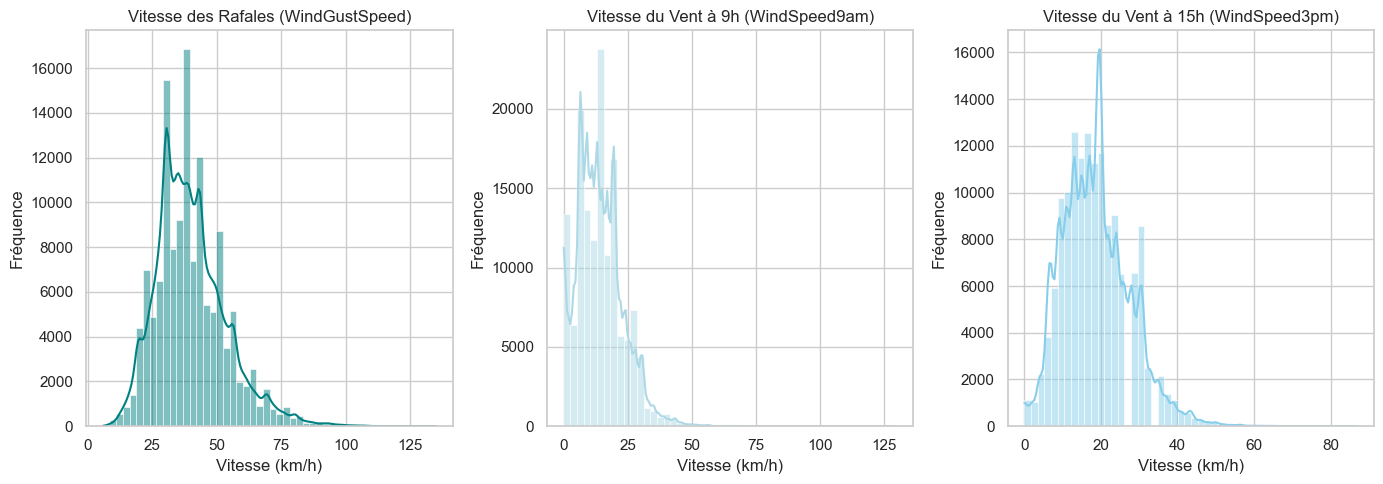

In [8]:
# CELL 3.D: Distribution des variables de vent

plt.figure(figsize=(14, 5))

plt.subplot(131)
sns.histplot(df['WindGustSpeed'], bins=50, color='teal', kde=True)
plt.title('Vitesse des Rafales (WindGustSpeed)')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Fréquence')

plt.subplot(132)
sns.histplot(df['WindSpeed9am'], bins=50, color='lightblue', kde=True)
plt.title('Vitesse du Vent à 9h (WindSpeed9am)')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Fréquence')

plt.subplot(133)
sns.histplot(df['WindSpeed3pm'], bins=50, color='skyblue', kde=True)
plt.title('Vitesse du Vent à 15h (WindSpeed3pm)')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../figures/etape1_05_distribution_vent.png', dpi=150)
plt.show()

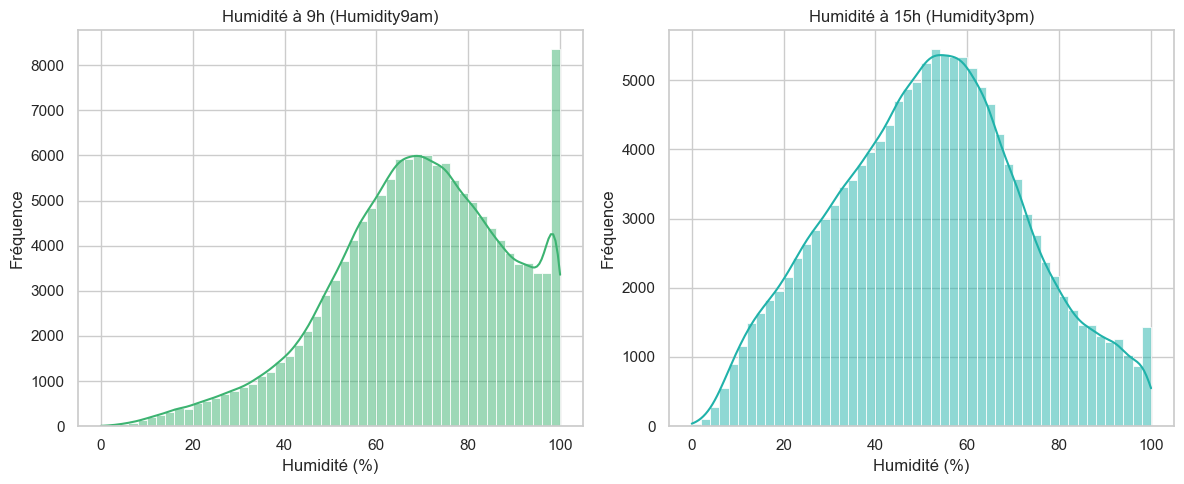

In [9]:
# CELL 3.E: Distribution de l'humidité

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Humidity9am'], bins=50, color='mediumseagreen', kde=True)
plt.title('Humidité à 9h (Humidity9am)')
plt.xlabel('Humidité (%)')
plt.ylabel('Fréquence')

plt.subplot(122)
sns.histplot(df['Humidity3pm'], bins=50, color='lightseagreen', kde=True)
plt.title('Humidité à 15h (Humidity3pm)')
plt.xlabel('Humidité (%)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../figures/etape1_06_distribution_humidite.png', dpi=150)
plt.show()

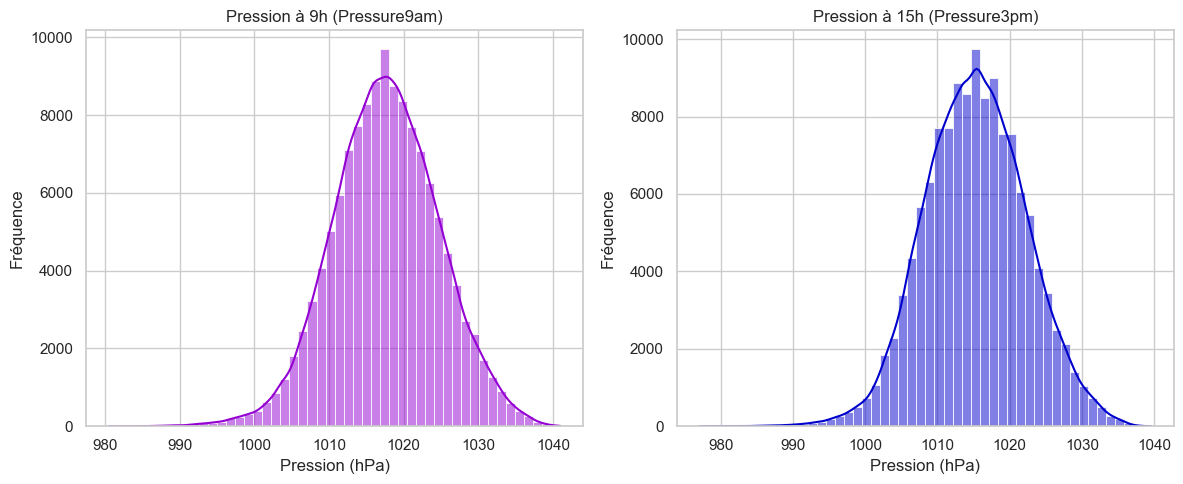

In [10]:
# CELL 3.F: Distribution de la pression atmosphérique

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Pressure9am'], bins=50, color='darkviolet', kde=True)
plt.title('Pression à 9h (Pressure9am)')
plt.xlabel('Pression (hPa)')
plt.ylabel('Fréquence')

plt.subplot(122)
sns.histplot(df['Pressure3pm'], bins=50, color='mediumblue', kde=True)
plt.title('Pression à 15h (Pressure3pm)')
plt.xlabel('Pression (hPa)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.savefig('../figures/etape1_07_distribution_pression.png', dpi=150)
plt.show()

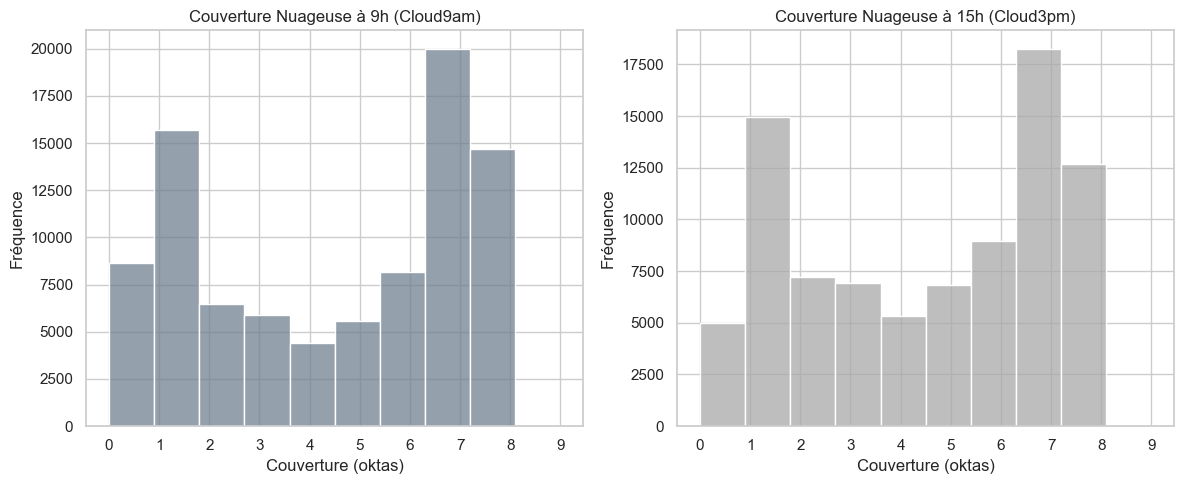

In [11]:
# CELL 3.G: Distribution de la couverture nuageuse

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Cloud9am'], bins=10, color='slategray', kde=False)
plt.title('Couverture Nuageuse à 9h (Cloud9am)')
plt.xlabel('Couverture (oktas)')
plt.ylabel('Fréquence')
plt.xticks(range(0, 10))

plt.subplot(122)
sns.histplot(df['Cloud3pm'], bins=10, color='darkgray', kde=False)
plt.title('Couverture Nuageuse à 15h (Cloud3pm)')
plt.xlabel('Couverture (oktas)')
plt.ylabel('Fréquence')
plt.xticks(range(0, 10))

plt.tight_layout()
plt.savefig('../figures/etape1_08_distribution_nuages.png', dpi=150)
plt.show()

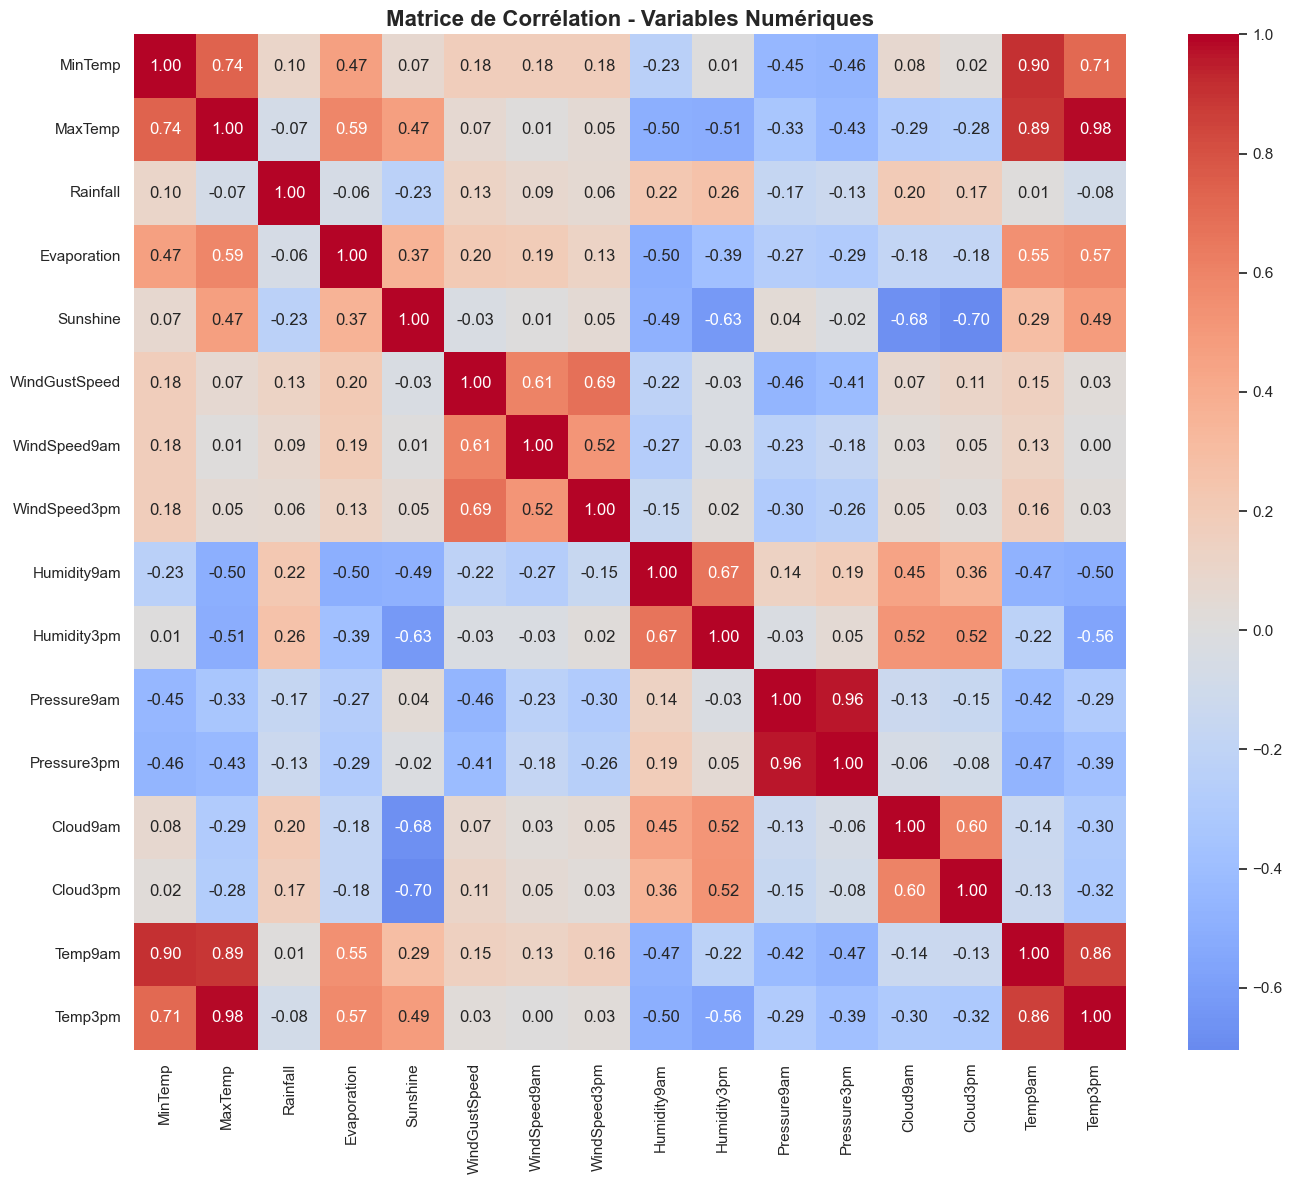

In [12]:
# CELL 4.A: Heatmap de corrélation entre variables numériques

# Sélectionner uniquement les variables numériques
numerical_cols = df.select_dtypes(include=['float64']).columns

# Calculer la matrice de corrélation
correlation_matrix = df[numerical_cols].corr()

# Créer la heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation - Variables Numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape1_09_heatmap_correlations.png', dpi=150)
plt.show()

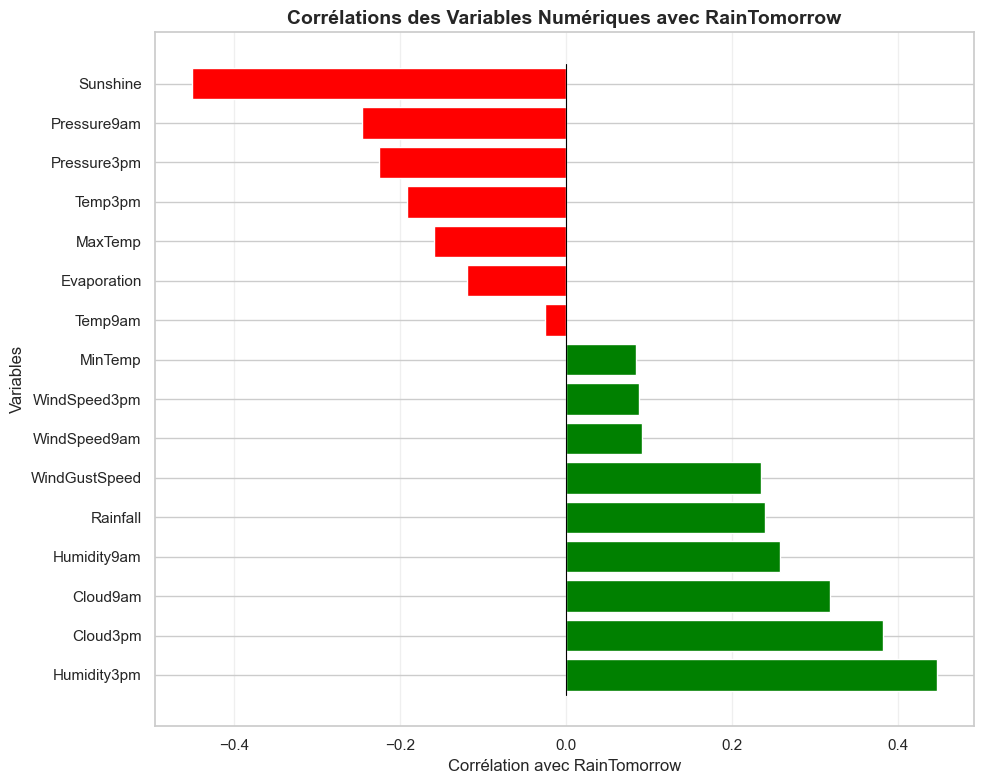

Corrélations avec RainTomorrow (ordre décroissant):
         Variable  Correlation
9     Humidity3pm     0.446160
13       Cloud3pm     0.381870
12       Cloud9am     0.317380
8     Humidity9am     0.257161
2        Rainfall     0.239032
5   WindGustSpeed     0.234010
6    WindSpeed9am     0.090995
7    WindSpeed3pm     0.087817
0         MinTemp     0.083936
14        Temp9am    -0.025691
3     Evaporation    -0.119285
1         MaxTemp    -0.159237
15        Temp3pm    -0.192424
11    Pressure3pm    -0.226031
10    Pressure9am    -0.246371
4        Sunshine    -0.450768


In [13]:
# CELL 4.B: Analyse des corrélations avec la variable cible

# Convertir RainTomorrow en numérique (Yes=1, No=0)
df['RainTomorrow_numeric'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Calculer les corrélations avec la cible, variable par variable
liste_correlations = []
for col in numerical_cols:
    liste_correlations.append(df['RainTomorrow_numeric'].corr(df[col]))

correlations_target = pd.DataFrame({'Variable': numerical_cols, 'Correlation': liste_correlations})
correlations_target = correlations_target.sort_values('Correlation', ascending=False)

# Créer le graphique
plt.figure(figsize=(10, 8))
colors = []
for x in correlations_target['Correlation']:
    if x > 0:
        colors.append('green')
    else:
        colors.append('red')
plt.barh(correlations_target['Variable'], correlations_target['Correlation'], color=colors)
# Ligne verticale de référence en 0
plt.plot([0, 0], [-0.5, len(correlations_target) - 0.5], color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Corrélation avec RainTomorrow')
plt.ylabel('Variables')
plt.title('Corrélations des Variables Numériques avec RainTomorrow', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/etape1_10_correlations_cible.png', dpi=150)
plt.show()

print("Corrélations avec RainTomorrow (ordre décroissant):")
print(correlations_target)

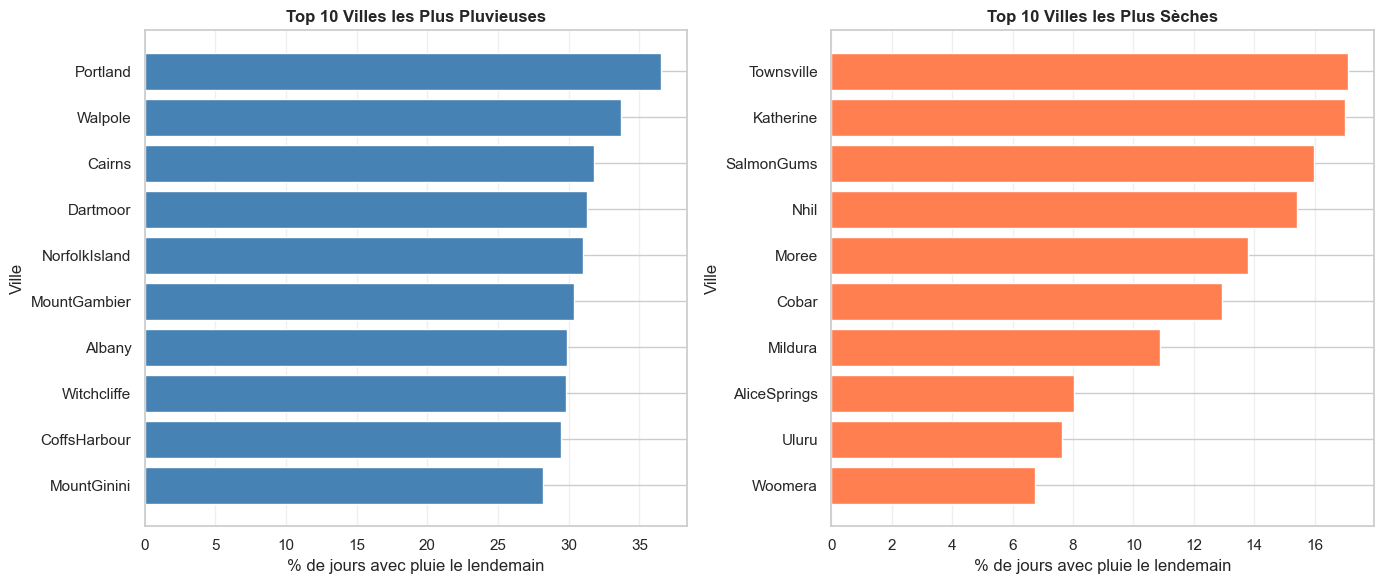

In [14]:
# CELL 4.C: Analyse géographique - Fréquence de pluie par ville

# Calculer le pourcentage de jours avec pluie par location
location_rain = df.groupby('Location')['RainTomorrow_numeric'].mean() * 100

# Top 10 villes les plus pluvieuses
top_10_rainy = location_rain.sort_values(ascending=False).head(10)

# Top 10 villes les plus sèches
top_10_dry = location_rain.sort_values(ascending=True).head(10)

# Créer le graphique
plt.figure(figsize=(14, 6))

plt.subplot(121)
top_10_rainy = top_10_rainy.sort_values()
plt.barh(top_10_rainy.index, top_10_rainy.values, color='steelblue')
plt.title('Top 10 Villes les Plus Pluvieuses', fontsize=12, fontweight='bold')
plt.xlabel('% de jours avec pluie le lendemain')
plt.ylabel('Ville')
plt.grid(axis='x', alpha=0.3)

plt.subplot(122)
top_10_dry = top_10_dry.sort_values()
plt.barh(top_10_dry.index, top_10_dry.values, color='coral')
plt.title('Top 10 Villes les Plus Sèches', fontsize=12, fontweight='bold')
plt.xlabel('% de jours avec pluie le lendemain')
plt.ylabel('Ville')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/etape1_11_pluie_par_localite.png', dpi=150)
plt.show()

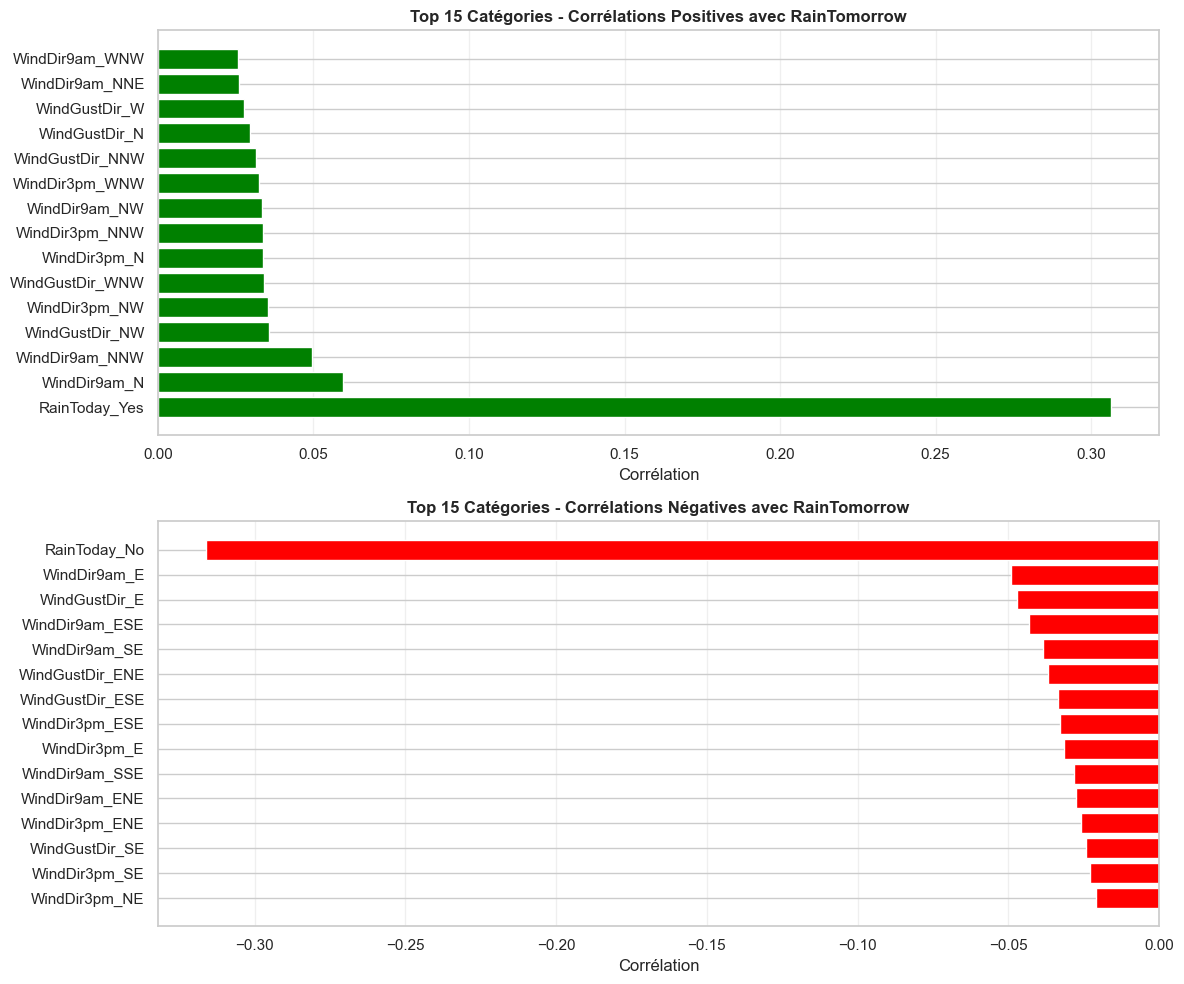

In [15]:
# CELL 4.D: Corrélations des variables catégorielles avec RainTomorrow

# Encoder les variables catégorielles
categorical_vars = ['RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

# One-hot encoding, liste des catégories obtenues
df_encoded = pd.get_dummies(df[categorical_vars], drop_first=False)
liste_categories = list(df_encoded.columns)

# Ajouter la variable cible numérique
df_encoded['RainTomorrow_numeric'] = df['RainTomorrow_numeric']

# Calculer les corrélations avec la cible, catégorie par catégorie
liste_correlations = []
for col in liste_categories:
    liste_correlations.append(df_encoded['RainTomorrow_numeric'].corr(df_encoded[col]))

cat_correlations = pd.DataFrame({'Categorie': liste_categories, 'Correlation': liste_correlations})
cat_correlations = cat_correlations.sort_values('Correlation', ascending=False)

# Afficher top 15 corrélations positives et négatives
top_15 = cat_correlations.head(15)
bottom_15 = cat_correlations.tail(15)

plt.figure(figsize=(12, 10))

plt.subplot(211)
plt.barh(top_15['Categorie'], top_15['Correlation'], color='green')
plt.title('Top 15 Catégories - Corrélations Positives avec RainTomorrow', fontsize=12, fontweight='bold')
plt.xlabel('Corrélation')
plt.grid(axis='x', alpha=0.3)

plt.subplot(212)
plt.barh(bottom_15['Categorie'], bottom_15['Correlation'], color='red')
plt.title('Top 15 Catégories - Corrélations Négatives avec RainTomorrow', fontsize=12, fontweight='bold')
plt.xlabel('Corrélation')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/etape1_12_correlations_categorielles_onehot.png', dpi=150)
plt.show()

In [16]:
# CELL 5.A: Test d'indépendance Chi-2 et V de Cramer : variables et seuils d'interprétation

from scipy.stats import chi2_contingency

# Rechargement pour garantir le dataset brut complet
df = pd.read_csv('../data/raw/weatherAUS.csv')

# Variables catégorielles à tester contre la cible RainTomorrow
variables_cat = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

def interpreter_cramer(v):
    # Seuils d'interprétation du V de Cramer
    if v >= 0.8:
        return 'Multicolinéarité suspectée'
    elif v >= 0.5:
        return 'Élevée'
    elif v >= 0.3:
        return 'Moyenne'
    else:
        return 'Faible'

In [17]:
# CELL 5.B: Test d'indépendance Chi-2 et V de Cramer (variables catégorielles vs cible)

resultats = []
for var in variables_cat:
    crosstab = pd.crosstab(df[var], df['RainTomorrow'])
    stat, p, dof, expected = chi2_contingency(crosstab)
    N = crosstab.values.sum()  # nombre d'observations non manquantes utilisées pour ce test
    # Cette forme de V de Cramer est exacte ici car la cible est binaire (min(r-1, k-1) = 1)
    V_Cramer = np.sqrt(stat / N)
    resultats.append({
        'Variable': var,
        'N': N,
        'Chi2': stat,
        'dof': dof,
        'p_valeur': p,
        'V_Cramer': V_Cramer,
        'Interprétation': interpreter_cramer(V_Cramer)
    })

resultats_cat = pd.DataFrame(resultats).sort_values('V_Cramer', ascending=False).reset_index().drop(columns=['index'])

In [18]:
# CELL 5.C: Affichage du test Chi-2 et du V de Cramer

# Mise en forme pour l'affichage
resultats_affichage = resultats_cat.copy()
chi2_arrondis = []
for x in resultats_affichage['Chi2'].values:
    chi2_arrondis.append(round(x, 2))
v_cramer_arrondis = []
for x in resultats_affichage['V_Cramer'].values:
    v_cramer_arrondis.append(round(x, 4))
resultats_affichage['Chi2'] = chi2_arrondis
resultats_affichage['V_Cramer'] = v_cramer_arrondis

print("Test d'indépendance Chi-2 et V de Cramer (variables catégorielles vs RainTomorrow):")
print(resultats_affichage)

Test d'indépendance Chi-2 et V de Cramer (variables catégorielles vs RainTomorrow):
      Variable       N      Chi2  dof       p_valeur  V_Cramer Interprétation
0    RainToday  140787  13799.48    1   0.000000e+00    0.3131        Moyenne
1     Location  142193   3544.79   48   0.000000e+00    0.1579         Faible
2   WindDir9am  132180   2214.85   15   0.000000e+00    0.1294         Faible
3  WindGustDir  132863   1519.90   15   0.000000e+00    0.1070         Faible
4   WindDir3pm  138415   1281.27   15  5.645749e-264    0.0962         Faible


Figure sauvegardée: figures/etape1_cramer_v_categorielles.png


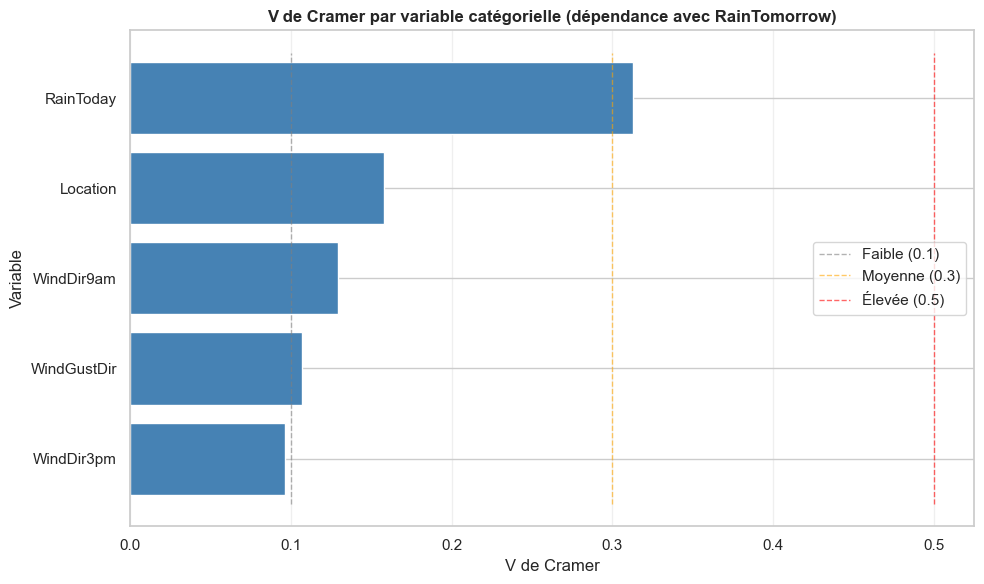

In [19]:
# CELL 6: Graphique V de Cramer par variable catégorielle

data_plot = resultats_cat.sort_values('V_Cramer', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(data_plot['Variable'], data_plot['V_Cramer'], color='steelblue')
# Lignes de référence des seuils d'interprétation
plt.plot([0.1, 0.1], [-0.5, len(data_plot) - 0.5], color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Faible (0.1)')
plt.plot([0.3, 0.3], [-0.5, len(data_plot) - 0.5], color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Moyenne (0.3)')
plt.plot([0.5, 0.5], [-0.5, len(data_plot) - 0.5], color='red', linestyle='--', linewidth=1, alpha=0.6, label='Élevée (0.5)')
plt.title('V de Cramer par variable catégorielle (dépendance avec RainTomorrow)', fontsize=12, fontweight='bold')
plt.xlabel('V de Cramer')
plt.ylabel('Variable')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/etape1_cramer_v_categorielles.png', dpi=150)
print("Figure sauvegardée: figures/etape1_cramer_v_categorielles.png")
plt.show()

Figure sauvegardée: figures/etape1_taux_pluie_par_categorie.png


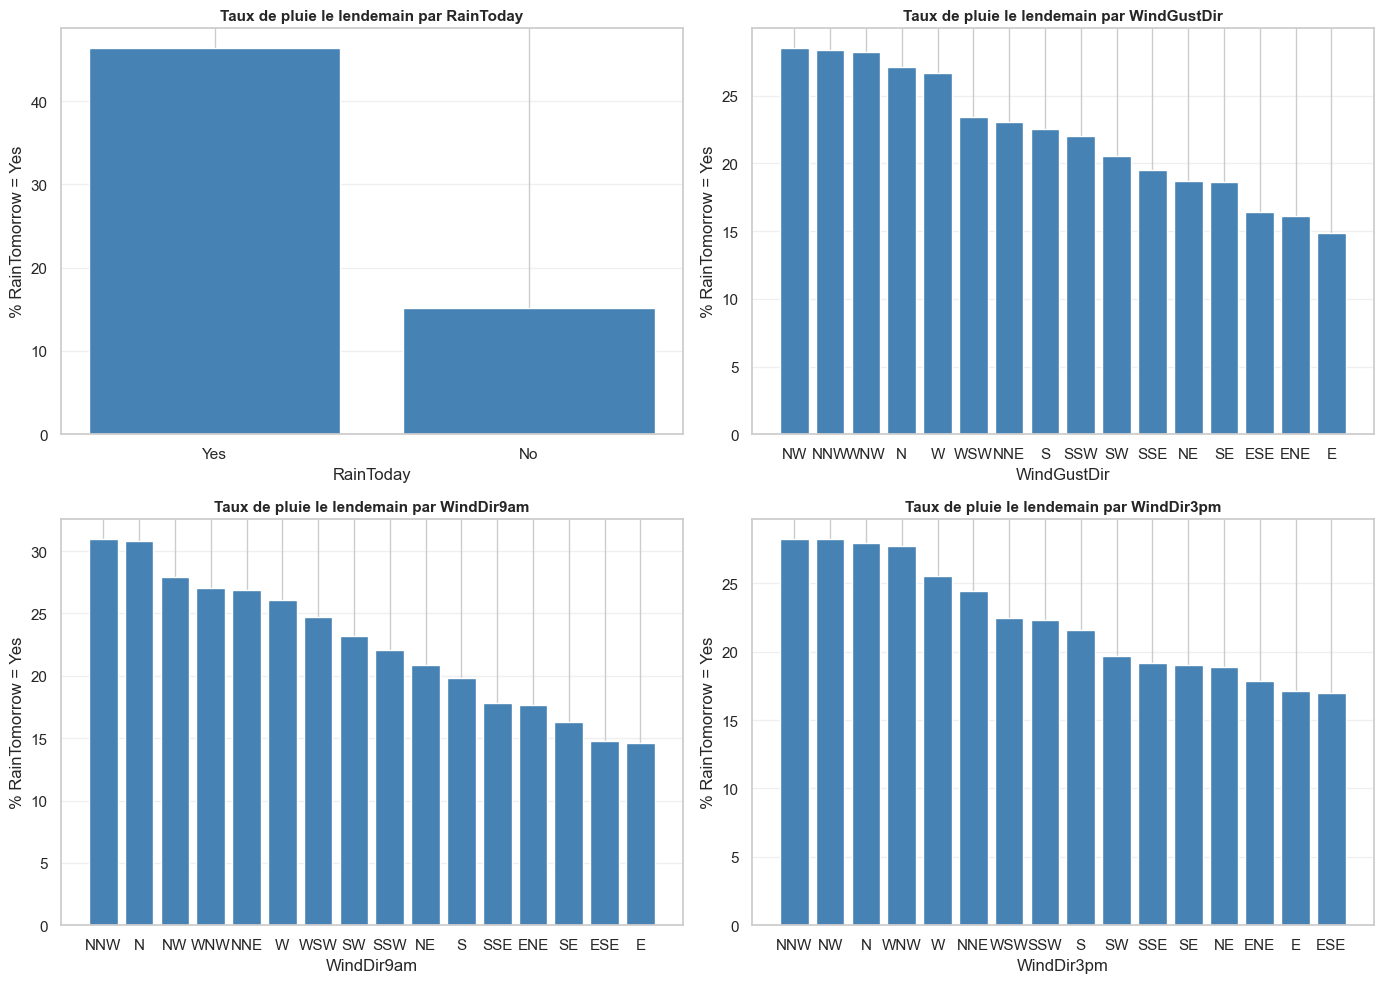

In [20]:
# CELL 7: Taux de pluie le lendemain par catégorie (visualisation de la dépendance)

# Cible binaire numérique : Yes = 1, No = 0, valeurs manquantes conservées pour être exclues des moyennes
df_taux = df.copy()
df_taux['cible_pluie'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

variables_grille = ['RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

plt.figure(figsize=(14, 10))

for i in range(len(variables_grille)):
    var = variables_grille[i]
    # Proportion de RainTomorrow = Yes dans chaque catégorie (en pourcentage)
    taux = df_taux.groupby(var)['cible_pluie'].mean() * 100
    taux = taux.sort_values(ascending=False)
    plt.subplot(2, 2, i + 1)
    plt.bar(taux.index.astype(str), taux.values, color='steelblue')
    plt.title(f"Taux de pluie le lendemain par {var}", fontsize=11, fontweight='bold')
    plt.xlabel(var)
    plt.ylabel('% RainTomorrow = Yes')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/etape1_taux_pluie_par_categorie.png', dpi=150)
print("Figure sauvegardée: figures/etape1_taux_pluie_par_categorie.png")
plt.show()

Figure sauvegardée: figures/etape1_boxplots_numeriques_vs_cible.png


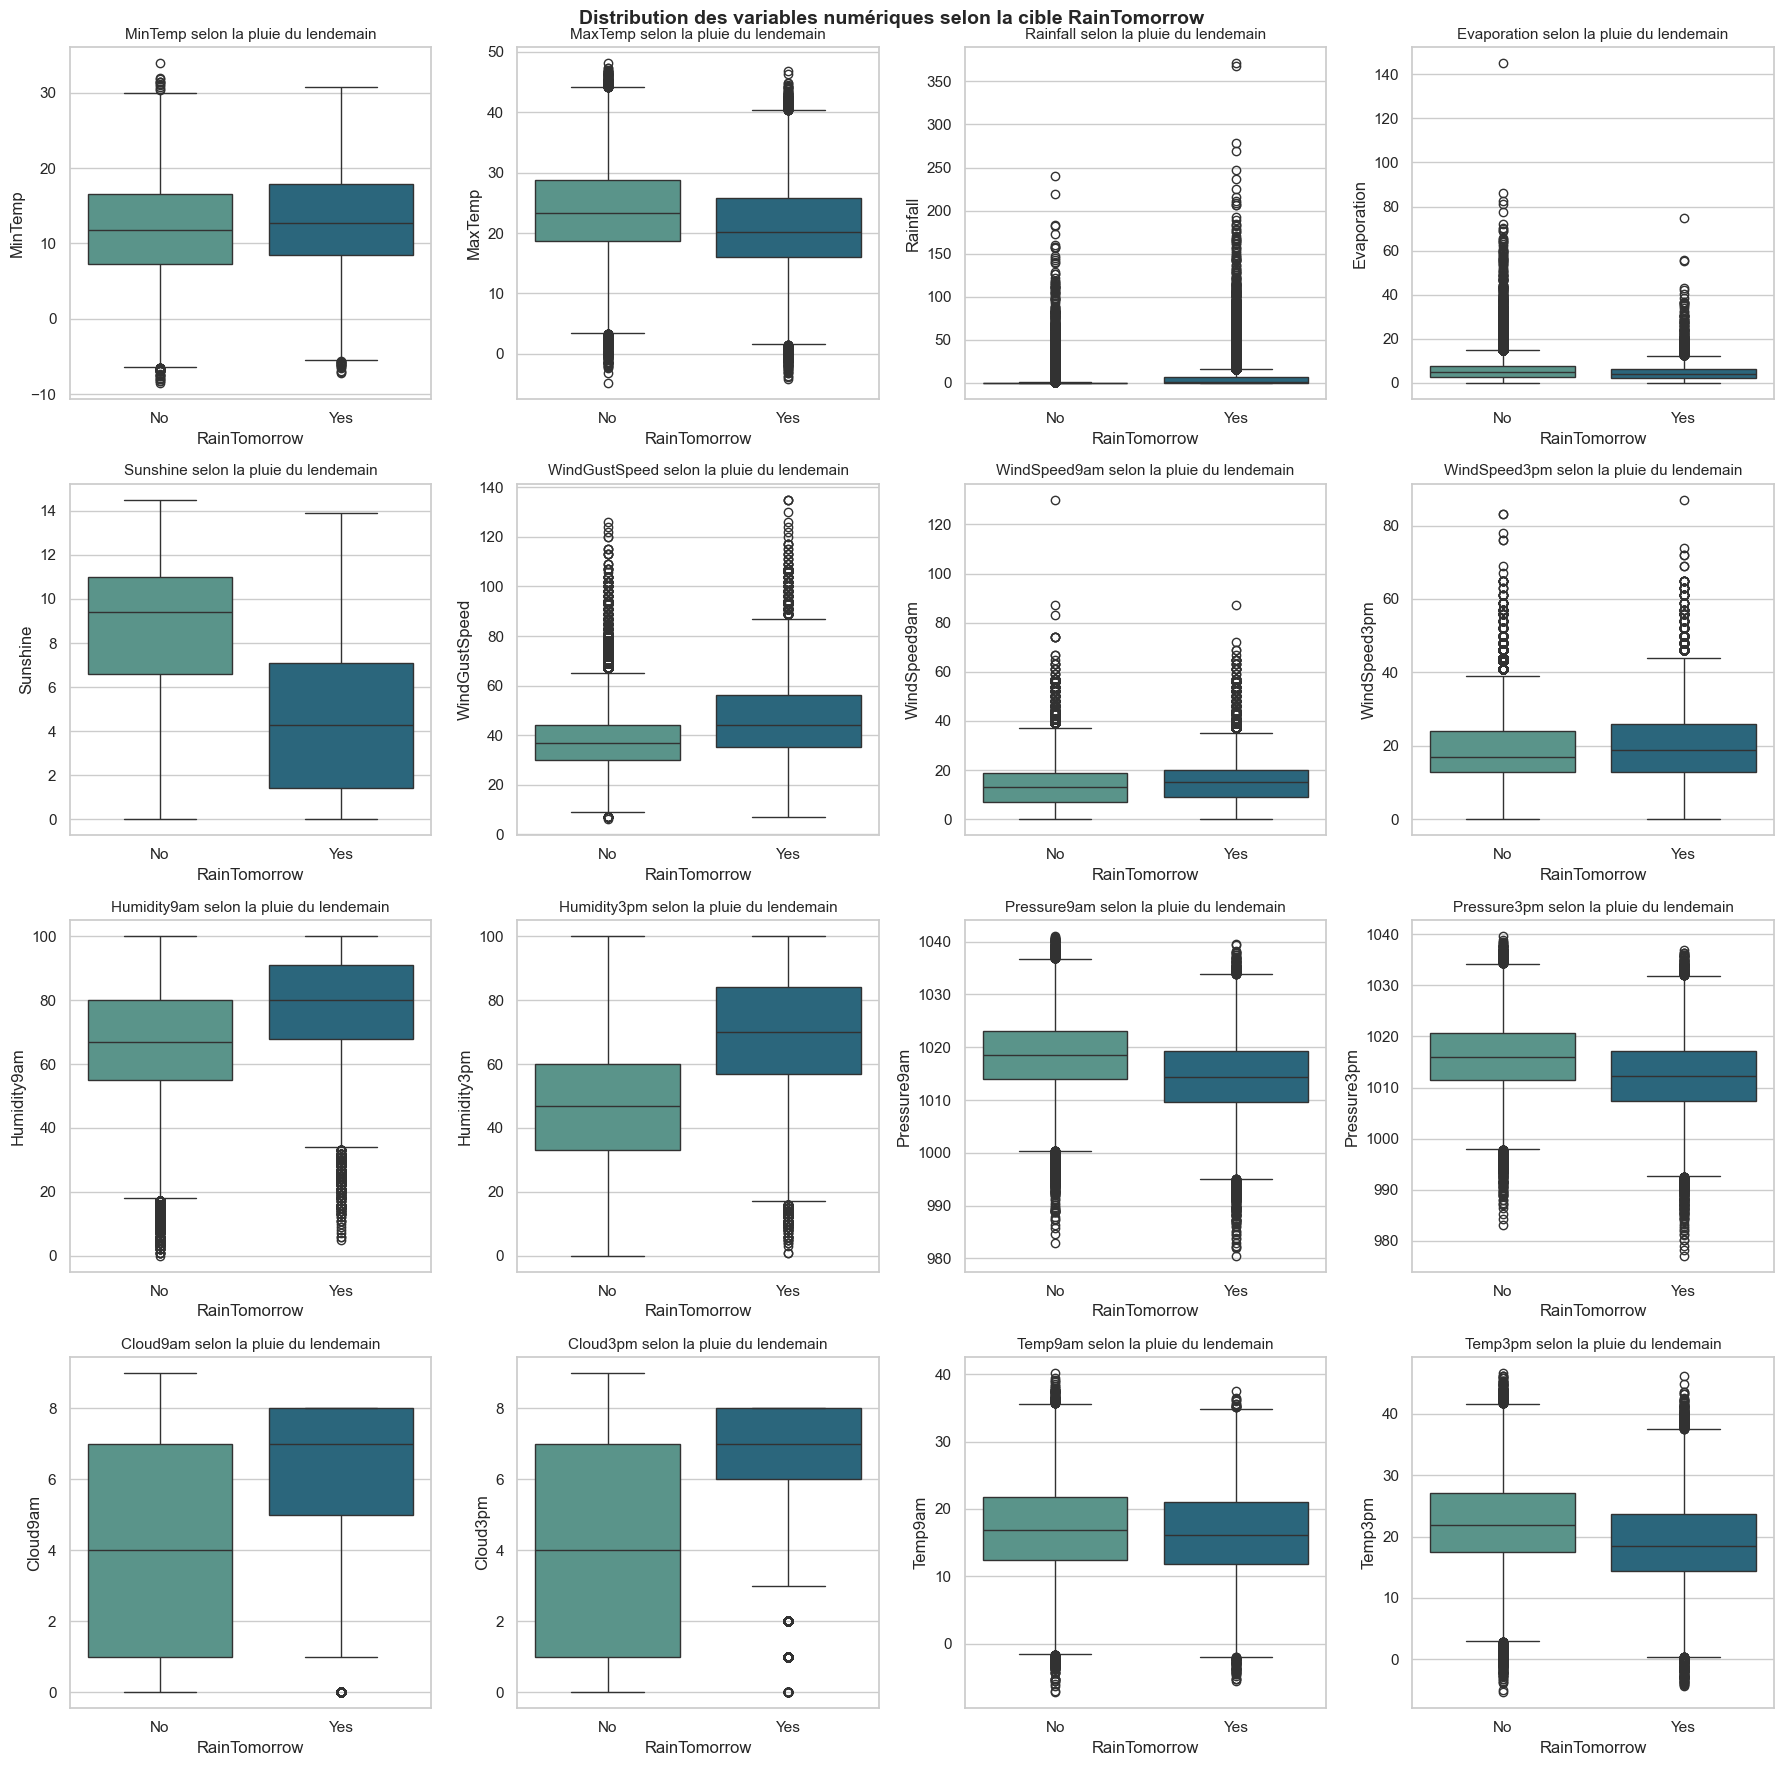

In [21]:
# CELL 8: Boxplots des variables numériques selon la cible (RainTomorrow)

# Rechargement pour garantir le dataset brut complet
df = pd.read_csv('../data/raw/weatherAUS.csv')

# EDA avant preprocessing : on inclut TOUTES les variables numériques (16),
# y compris les quatre à forte proportion de valeurs manquantes (Evaporation, Sunshine, Cloud9am, Cloud3pm)
variables_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

# On conserve uniquement les lignes où la cible vaut 'No' ou 'Yes' (exclusion des NaN)
df_box = df[df['RainTomorrow'].isin(['No', 'Yes'])]

# Grille 4x4 : une variable par sous-graphique, outliers conservés
plt.figure(figsize=(18, 18))

for i in range(len(variables_num)):
    var = variables_num[i]
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x='RainTomorrow', y=var, data=df_box, palette='crest', order=['No', 'Yes'])
    plt.title(f"{var} selon la pluie du lendemain", fontsize=11)
    plt.xlabel('RainTomorrow')
    plt.ylabel(var)

plt.suptitle("Distribution des variables numériques selon la cible RainTomorrow",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape1_boxplots_numeriques_vs_cible.png', dpi=150)
print("Figure sauvegardée: figures/etape1_boxplots_numeriques_vs_cible.png")
plt.show()

In [22]:
# CELL 9: Chiffres clés du jeu de données

# Rechargement pour garantir le dataset brut complet
df = pd.read_csv('../data/raw/weatherAUS.csv')

# Dimensions et valeurs manquantes
print(f"Dimensions: {df.shape[0]} lignes x {df.shape[1]} colonnes")
pct_lignes_na = df.isnull().any(axis=1).mean() * 100
print(f"Lignes avec au moins une valeur manquante: {pct_lignes_na:.2f}%")

# Période couverte (les 10 premiers caractères de la date : AAAA-MM-JJ)
dates = pd.to_datetime(df['Date'])
print(f"Date minimale: {str(dates.min())[:10]}")
print(f"Date maximale: {str(dates.max())[:10]}")

# Localités
print(f"Nombre de localités distinctes: {df['Location'].nunique()}")

# Cible
cible_connue = df['RainTomorrow'].dropna()
pct_yes = (cible_connue == 'Yes').mean() * 100
print(f"RainTomorrow = Yes (parmi les cibles non manquantes): {pct_yes:.2f}%")
print(f"RainTomorrow manquant: {df['RainTomorrow'].isnull().sum()}")

# Taux de pluie le lendemain pour chaque localité (cibles non manquantes uniquement)
df_cible = df[df['RainTomorrow'].isin(['No', 'Yes'])]
taux_localite = (df_cible['RainTomorrow'] == 'Yes').groupby(df_cible['Location']).mean() * 100
taux_localite = taux_localite.sort_values(ascending=False)

print(f"\nTaux de pluie le lendemain par localité ({len(taux_localite)} localités, ordre décroissant):")
for loc, taux in taux_localite.items():
    print(f"  {loc} {taux:.2f}%")

# Le tri décroissant place la localité la plus pluvieuse en premier et la plus sèche en dernier
ratio = taux_localite.max() / taux_localite.min()
print(f"\nTaux max: {taux_localite.max():.2f}% ({taux_localite.index[0]})")
print(f"Taux min: {taux_localite.min():.2f}% ({taux_localite.index[-1]})")
print(f"Ratio taux max / taux min: {ratio:.2f}")

# Corrélations de Pearson entre paires de variables (lignes complètes pour chaque paire)
paires = [('MaxTemp', 'Humidity3pm'), ('Temp9am', 'Temp3pm'), ('MinTemp', 'Temp9am'),
          ('MaxTemp', 'Temp3pm'), ('Pressure9am', 'Pressure3pm')]

print("\nCorrélations de Pearson entre paires de variables:")
for var1, var2 in paires:
    r = df[var1].corr(df[var2], method='pearson')
    print(f"  {var1} - {var2}: {r:.4f}")

Dimensions: 145460 lignes x 23 colonnes
Lignes avec au moins une valeur manquante: 61.21%
Date minimale: 2007-11-01
Date maximale: 2017-06-25
Nombre de localités distinctes: 49
RainTomorrow = Yes (parmi les cibles non manquantes): 22.42%
RainTomorrow manquant: 3267

Taux de pluie le lendemain par localité (49 localités, ordre décroissant):
  Portland 36.55%
  Walpole 33.66%
  Cairns 31.79%
  Dartmoor 31.33%
  NorfolkIsland 31.01%
  MountGambier 30.36%
  Albany 29.91%
  Witchcliffe 29.78%
  CoffsHarbour 29.43%
  MountGinini 28.17%
  NorahHead 27.59%
  Williamtown 27.42%
  Darwin 26.69%
  Melbourne 26.12%
  GoldCoast 26.01%
  Sydney 25.92%
  Ballarat 25.79%
  SydneyAirport 25.76%
  Newcastle 24.74%
  Watsonia 24.61%
  Wollongong 23.90%
  Hobart 23.87%
  Launceston 23.08%
  Brisbane 22.43%
  Adelaide 22.27%
  MelbourneAirport 21.70%
  Sale 21.43%
  Albury 20.52%
  Perth 20.20%
  Penrith 20.07%
  BadgerysCreek 19.91%
  Nuriootpa 19.72%
  Richmond 18.98%
  Tuggeranong 18.95%
  PerthAirport 

In [23]:
# CELL 10.A: Corrélations de Pearson et de Spearman avec la cible (variables brutes)

from scipy.stats import pearsonr, spearmanr

# Cible binaire numérique : Yes = 1, No = 0 (NaN conservés pour être exclus ensuite)
df['cible'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Les 16 variables numériques brutes, y compris celles à forte proportion de valeurs manquantes
variables_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

lignes = []
for var in variables_num:
    # On retire les lignes où la variable ou la cible est manquante
    donnees = df[[var, 'cible']].dropna()
    p = pearsonr(donnees[var], donnees['cible'])[0]
    s = spearmanr(donnees[var], donnees['cible'])[0]
    lignes.append({
        'Variable': var,
        'N': len(donnees),
        'Pearson': round(p, 4),
        'Spearman': round(s, 4)
    })

table_corr_brut = pd.DataFrame(lignes)
# Tri par |Spearman| décroissant : colonne de la valeur absolue, tri, puis suppression de la colonne
table_corr_brut['abs_Spearman'] = np.abs(table_corr_brut['Spearman'])
table_corr_brut = table_corr_brut.sort_values('abs_Spearman', ascending=False).reset_index().drop(columns=['index'])
table_corr_brut = table_corr_brut.drop(columns=['abs_Spearman'])

print("Corrélation avec la cible (données brutes) : Pearson vs Spearman")
print(table_corr_brut)

Corrélation avec la cible (données brutes) : Pearson vs Spearman
         Variable       N  Pearson  Spearman
0        Sunshine   74377  -0.4508   -0.4385
1     Humidity3pm  138583   0.4462    0.4312
2        Cloud3pm   85099   0.3819    0.3941
3        Rainfall  140787   0.2390    0.3318
4        Cloud9am   88536   0.3174    0.3246
5     Humidity9am  140419   0.2572    0.2672
6     Pressure9am  128179  -0.2464   -0.2358
7     Pressure3pm  128212  -0.2260   -0.2154
8   WindGustSpeed  132923   0.2340    0.2124
9         Temp3pm  139467  -0.1924   -0.1931
10        MaxTemp  141871  -0.1592   -0.1588
11    Evaporation   81350  -0.1193   -0.1376
12   WindSpeed9am  140845   0.0910    0.0814
13        MinTemp  141556   0.0839    0.0765
14   WindSpeed3pm  139563   0.0878    0.0763
15        Temp9am  141289  -0.0257   -0.0303



Figure sauvegardée: figures/etape1_13_pearson_vs_spearman_brut.png


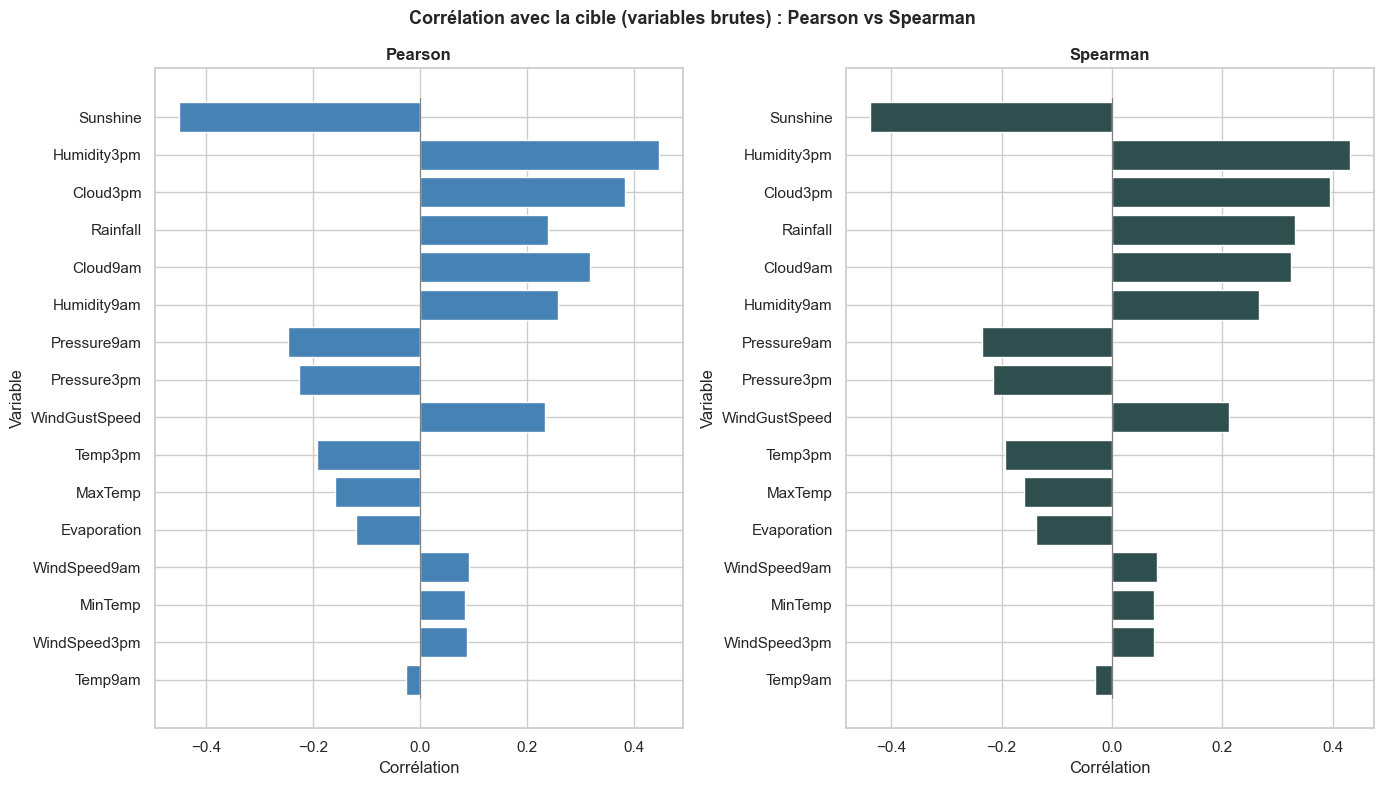

In [24]:
# CELL 10.B: Graphique des corrélations de Pearson et de Spearman avec la cible (variables brutes)

# Barres horizontales (noms de variables lisibles sans rotation), même ordre dans les deux panneaux :
# la variable la plus corrélée (|Spearman|) en haut
donnees_graphique = table_corr_brut.sort_index(ascending=False)

plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.barh(donnees_graphique['Variable'], donnees_graphique['Pearson'], color='steelblue')
# Ligne verticale de référence en 0
plt.plot([0, 0], [-0.5, len(donnees_graphique) - 0.5], color='gray', linewidth=0.8)
plt.title("Pearson", fontsize=12, fontweight='bold')
plt.xlabel("Corrélation")
plt.ylabel("Variable")

plt.subplot(1, 2, 2)
plt.barh(donnees_graphique['Variable'], donnees_graphique['Spearman'], color='darkslategray')
plt.plot([0, 0], [-0.5, len(donnees_graphique) - 0.5], color='gray', linewidth=0.8)
plt.title("Spearman", fontsize=12, fontweight='bold')
plt.xlabel("Corrélation")
plt.ylabel("Variable")

plt.suptitle("Corrélation avec la cible (variables brutes) : Pearson vs Spearman", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape1_13_pearson_vs_spearman_brut.png', dpi=150)
print("\nFigure sauvegardée: figures/etape1_13_pearson_vs_spearman_brut.png")
plt.show()